# cross_arch — Step A: cross-architecture replication of the L4→L5 transition

Question: is the per-patch differential-entropy phase transition seen in
ViT-B/16 (L4→L5) specific to that arch, or shared across the ViT family?

Method: run the entropy-stack pipeline (`eris.extract.extract_entropy_stack`)
on the **same 200 images** from `Maysee/tiny-imagenet` validation, on each of:

- `google/vit-base-patch16-224`     — `vit_b16`   (12 blocks)
- `google/vit-large-patch16-224`    — `vit_l16`   (24 blocks)
- `facebook/dinov2-base`            — `dinov2_b`  (12 blocks, self-supervised)
- `openai/clip-vit-base-patch16`    — `clip_b16`  (12 blocks, contrastive)

For each image we compute the transition layer = argmax over `L` of
the within-layer ΔH-std (`eris.fields.transition_layer`). We aggregate
per-arch with **median ± bootstrap CI** of `L_trans / L_max` (relative
depth). The headline figure overlays per-arch ΔH-std vs `L/L_max` with
bootstrap bands.

Stop condition: if 3+ archs show no coherent transition we surface
the negative result and skip figure polishing.

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from PIL import Image

from eris.extract import extract_entropy_stack
from eris.fields import per_layer_stats, transition_layer

In [2]:
try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
REPO = NB_DIR if (NB_DIR / "pyproject.toml").exists() else NB_DIR.parent
RESULTS = REPO / "results" / "cross_arch"
RESULTS.mkdir(parents=True, exist_ok=True)

ARCHS = ["vit_b16", "vit_l16", "dinov2_b", "clip_b16"]
N_IMAGES = 200
N_BOOT = 2000
SEED = 0
print(f"REPO    = {REPO}")
print(f"RESULTS = {RESULTS}")
print(f"archs   = {ARCHS}")
print(f"N       = {N_IMAGES} images, bootstrap = {N_BOOT}")

REPO    = /home/varun/research/eris
RESULTS = /home/varun/research/eris/results/cross_arch
archs   = ['vit_b16', 'vit_l16', 'dinov2_b', 'clip_b16']
N       = 200 images, bootstrap = 2000


## 1. Image set

Same 200 RGB images sampled deterministically from the validation split.
Tiny-imagenet is 64×64; the per-arch `AutoImageProcessor` resizes to
the model's expected input (224×224 for all four).

In [3]:
ds = load_dataset("Maysee/tiny-imagenet", split="valid")
rng = np.random.default_rng(SEED)
indices = rng.choice(len(ds), size=N_IMAGES, replace=False)
indices.sort()
images: list[Image.Image] = [ds[int(i)]["image"].convert("RGB") for i in indices]
print(f"selected {len(images)} images, first 5 idx = {indices[:5].tolist()}")

selected 200 images, first 5 idx = [26, 52, 81, 146, 162]


## 2. Run each arch

We persist the full `(n_imgs, n_layers, gy, gx)` H_stack tensor per arch
(uncompressed `.npz` is fine — 200·24·16·16·4B ≈ 5 MB worst case).

In [4]:
def run_arch(arch: str) -> tuple[np.ndarray, dict]:
    arch_dir = RESULTS / arch
    arch_dir.mkdir(exist_ok=True, parents=True)
    npz_path = arch_dir / "H_stack.npz"
    if npz_path.exists():
        z = np.load(npz_path)
        H = z["H"]
        spec_dict = json.loads(z["spec"].item())
        print(f"[{arch}] cached: H={H.shape}")
        return H, spec_dict
    print(f"[{arch}] running over {len(images)} images...")
    t0 = time.time()
    H, spec = extract_entropy_stack(arch, images, device="cuda")
    dt = time.time() - t0
    spec_dict = {
        "model_name": spec.model_name,
        "has_cls": spec.has_cls,
        "grid_size": list(spec.grid_size),
        "n_layers": spec.n_layers,
        "hidden_dim": spec.hidden_dim,
    }
    np.savez(npz_path, H=H.astype(np.float32),
             spec=np.array(json.dumps(spec_dict)),
             image_indices=indices)
    print(f"[{arch}] done in {dt:.1f}s -> {npz_path.relative_to(REPO)}  H={H.shape}")
    return H, spec_dict


H_per_arch: dict[str, np.ndarray] = {}
spec_per_arch: dict[str, dict] = {}
for arch in ARCHS:
    H, spec_dict = run_arch(arch)
    H_per_arch[arch] = H
    spec_per_arch[arch] = spec_dict
    # free GPU between archs
    import gc, torch
    gc.collect(); torch.cuda.empty_cache()

[vit_b16] running over 200 images...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[vit_b16] done in 77.7s -> results/cross_arch/vit_b16/H_stack.npz  H=(200, 12, 14, 14)
[vit_l16] running over 200 images...


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

[clip_b16] done in 79.7s -> results/cross_arch/clip_b16/H_stack.npz  H=(200, 12, 14, 14)


## 3. Per-image transition layers and per-layer stats

For each arch:
- `L_trans`: per-image argmax of ΔH-std (already implemented in
  `eris.fields.transition_layer`).
- `dH_std_imgs`: shape `(n_imgs, n_layers)` — per-image curve. The
  first entry is 0 by convention (no L→L-1 difference for L=1).
- bootstrap CI of `median(L_trans / L_max)` across images.

In [5]:
def bootstrap_ci(values: np.ndarray, n_boot: int = N_BOOT,
                 alpha: float = 0.05, seed: int = SEED) -> tuple[float, float]:
    """Percentile bootstrap CI of the median."""
    rng = np.random.default_rng(seed)
    n = len(values)
    samples = rng.choice(values, size=(n_boot, n), replace=True)
    medians = np.median(samples, axis=1)
    lo = float(np.quantile(medians, alpha / 2.0))
    hi = float(np.quantile(medians, 1.0 - alpha / 2.0))
    return lo, hi


def bootstrap_curve_band(curves: np.ndarray, n_boot: int = N_BOOT,
                         alpha: float = 0.05, seed: int = SEED
                         ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Per-position bootstrap band of the mean of `curves` (n_imgs, n_pts)."""
    rng = np.random.default_rng(seed)
    n = curves.shape[0]
    means = np.empty((n_boot, curves.shape[1]), dtype=np.float64)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[b] = curves[idx].mean(axis=0)
    lo = np.quantile(means, alpha / 2.0, axis=0)
    hi = np.quantile(means, 1.0 - alpha / 2.0, axis=0)
    mid = curves.mean(axis=0)
    return mid, lo, hi


summary: dict[str, dict] = {}
dH_std_per_arch: dict[str, np.ndarray] = {}
L_trans_per_arch: dict[str, np.ndarray] = {}

for arch in ARCHS:
    H = H_per_arch[arch]                          # (n_imgs, L, gy, gx)
    n_imgs, L_max = H.shape[0], H.shape[1]
    L_trans = np.array([transition_layer(H[i]) for i in range(n_imgs)],
                       dtype=np.int32)
    # per-image dH_std curve (length L)
    dH_std = np.zeros((n_imgs, L_max), dtype=np.float64)
    for i in range(n_imgs):
        s = per_layer_stats(H[i])
        dH_std[i] = s["dH_std"]                   # already prefixed with 0

    rel = L_trans / L_max
    med = float(np.median(rel))
    lo, hi = bootstrap_ci(rel)
    summary[arch] = {
        "model_name": spec_per_arch[arch]["model_name"],
        "n_layers": int(L_max),
        "n_images": int(n_imgs),
        "median_L_trans": float(np.median(L_trans)),
        "median_L_trans_rel": med,
        "ci95_L_trans_rel_lo": lo,
        "ci95_L_trans_rel_hi": hi,
        "L_trans_iqr": [float(np.quantile(L_trans, 0.25)),
                        float(np.quantile(L_trans, 0.75))],
        "L_trans_min": int(L_trans.min()),
        "L_trans_max": int(L_trans.max()),
    }
    dH_std_per_arch[arch] = dH_std
    L_trans_per_arch[arch] = L_trans

    arch_dir = RESULTS / arch
    np.save(arch_dir / "transition_layer.npy", L_trans)
    with (arch_dir / "transition_summary.json").open("w") as fh:
        json.dump(summary[arch], fh, indent=2)
    print(f"[{arch}] L_max={L_max}  L_trans median={summary[arch]['median_L_trans']:.1f}"
          f"  rel={med:.3f} CI95=[{lo:.3f}, {hi:.3f}]"
          f"  L_trans range=[{summary[arch]['L_trans_min']}, {summary[arch]['L_trans_max']}]")

[vit_b16] L_max=12  L_trans median=5.0  rel=0.417 CI95=[0.417, 0.417]  L_trans range=[4, 5]
[vit_l16] L_max=24  L_trans median=5.0  rel=0.208 CI95=[0.208, 0.208]  L_trans range=[5, 6]
[dinov2_b] L_max=12  L_trans median=8.0  rel=0.667 CI95=[0.667, 0.667]  L_trans range=[8, 8]


[clip_b16] L_max=12  L_trans median=7.0  rel=0.583 CI95=[0.583, 0.583]  L_trans range=[6, 11]


## 4. Coherence diagnostic (stop condition)

A transition is **coherent** in arch `A` if:
1. The per-image `L_trans` distribution is concentrated (IQR ≤ 25 % of
   `L_max` — i.e. at most a quarter of depth).
2. The mean ΔH-std curve has a single dominant peak (peak / median ≥ 2).

These are heuristic; we record both per-arch and report the
coherent-arch count. Stop if < 2 archs are coherent (i.e. ≥ 3 fail).

In [6]:
def coherence(L_trans: np.ndarray, dH_std: np.ndarray, L_max: int) -> dict:
    iqr = float(np.quantile(L_trans, 0.75) - np.quantile(L_trans, 0.25))
    iqr_rel = iqr / L_max
    mean_curve = dH_std.mean(axis=0)
    # peak strength relative to median (skip the L=1 zero entry)
    if L_max > 1:
        body = mean_curve[1:]
        peak = float(body.max())
        med = float(np.median(body) + 1e-12)
        peak_to_med = peak / med
    else:
        peak_to_med = 0.0
    is_coherent = (iqr_rel <= 0.25) and (peak_to_med >= 2.0)
    return {
        "L_trans_iqr": iqr,
        "L_trans_iqr_rel": iqr_rel,
        "peak_to_median_ratio": peak_to_med,
        "is_coherent": bool(is_coherent),
    }


for arch in ARCHS:
    c = coherence(L_trans_per_arch[arch], dH_std_per_arch[arch],
                  H_per_arch[arch].shape[1])
    summary[arch].update(c)
    with (RESULTS / arch / "transition_summary.json").open("w") as fh:
        json.dump(summary[arch], fh, indent=2)
    flag = "OK" if c["is_coherent"] else "FAIL"
    print(f"[{arch}] coherence: IQR_rel={c['L_trans_iqr_rel']:.3f}"
          f"  peak/med={c['peak_to_median_ratio']:.2f}  -> {flag}")

n_coherent = sum(1 for a in ARCHS if summary[a]["is_coherent"])
stop_triggered = n_coherent < 2     # fewer than 2 coherent => 3+ fail
print(f"\ncoherent archs: {n_coherent} / {len(ARCHS)};  "
      f"stop_condition_triggered={stop_triggered}")

[vit_b16] coherence: IQR_rel=0.000  peak/med=9.30  -> OK
[vit_l16] coherence: IQR_rel=0.000  peak/med=21.23  -> OK
[dinov2_b] coherence: IQR_rel=0.000  peak/med=4.97  -> OK
[clip_b16] coherence: IQR_rel=0.000  peak/med=4.00  -> OK

coherent archs: 4 / 4;  stop_condition_triggered=False


## 5. Headline figure

Top strip: a representative grid of the 200 input images (12 thumbnails).
Main panel: per-arch mean ΔH-std vs relative depth `L/L_max` with the
bootstrap mean band. We plot at the per-arch native depth grid (no
interpolation — keeps the discrete transition visible).

We also annotate each arch's median L_trans / L_max.

saved /home/varun/research/eris/results/cross_arch_phase_transition.png


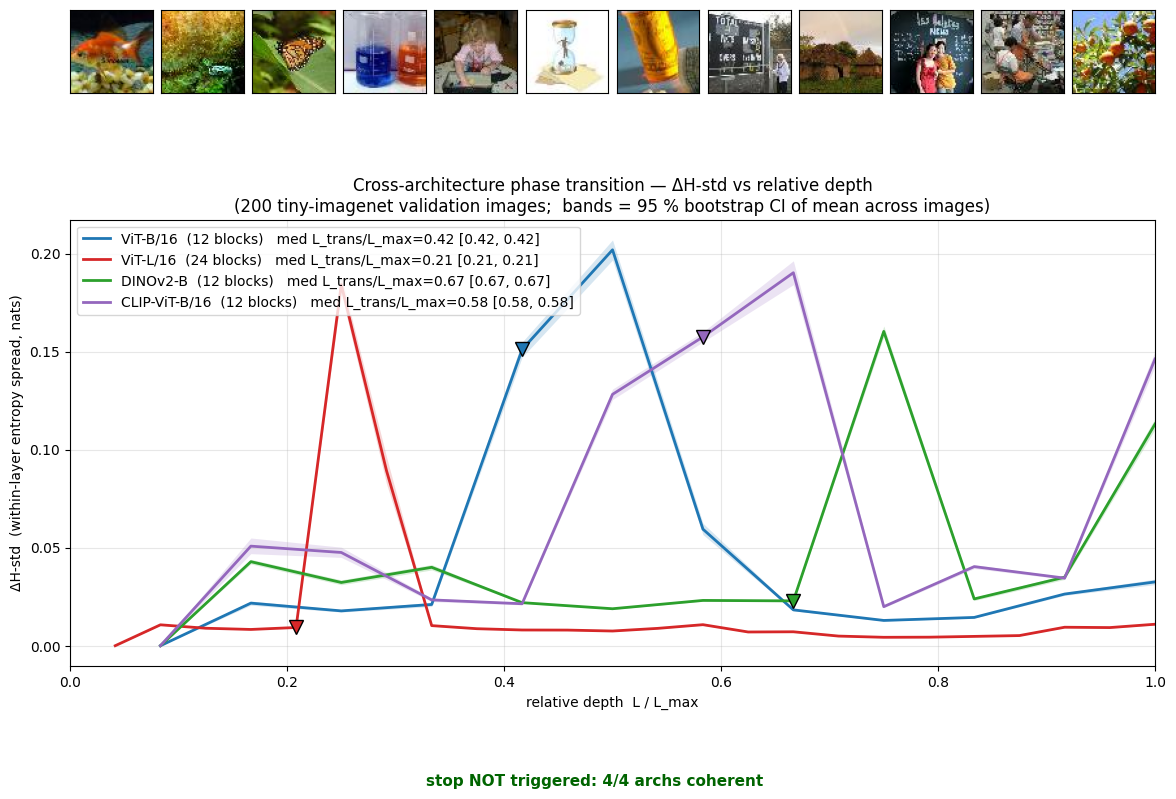

In [7]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    nrows=2, ncols=12,
    height_ratios=[0.35, 1.0],
    hspace=0.30, wspace=0.10,
)

# 12-image strip across the top, evenly sampled from the 200.
strip_idx = np.linspace(0, len(images) - 1, 12).astype(int)
for c, ii in enumerate(strip_idx):
    ax = fig.add_subplot(gs[0, c])
    ax.imshow(images[ii])
    ax.set_xticks([]); ax.set_yticks([])

# Main panel.
ax = fig.add_subplot(gs[1, :])
arch_colors = {
    "vit_b16":  "#1f77b4",
    "vit_l16":  "#d62728",
    "dinov2_b": "#2ca02c",
    "clip_b16": "#9467bd",
}
arch_labels = {
    "vit_b16":  "ViT-B/16  (12 blocks)",
    "vit_l16":  "ViT-L/16  (24 blocks)",
    "dinov2_b": "DINOv2-B  (12 blocks)",
    "clip_b16": "CLIP-ViT-B/16  (12 blocks)",
}
for arch in ARCHS:
    L_max = H_per_arch[arch].shape[1]
    rel_depth = (np.arange(1, L_max + 1)) / L_max     # L=1..L_max → 1/L..1
    mid, lo, hi = bootstrap_curve_band(dH_std_per_arch[arch])
    c = arch_colors[arch]
    ax.plot(rel_depth, mid, color=c, lw=2.0,
            label=f"{arch_labels[arch]}   "
                  f"med L_trans/L_max={summary[arch]['median_L_trans_rel']:.2f}"
                  f" [{summary[arch]['ci95_L_trans_rel_lo']:.2f}, "
                  f"{summary[arch]['ci95_L_trans_rel_hi']:.2f}]")
    ax.fill_between(rel_depth, lo, hi, color=c, alpha=0.18, lw=0)
    # mark median transition with a small triangle
    rt = summary[arch]["median_L_trans_rel"]
    yt = float(np.interp(rt, rel_depth, mid))
    ax.plot([rt], [yt], marker="v", color=c, markersize=10,
            markeredgecolor="black", linestyle="None")

ax.set_xlabel("relative depth  L / L_max")
ax.set_ylabel("ΔH-std  (within-layer entropy spread, nats)")
ax.set_title("Cross-architecture phase transition — ΔH-std vs relative depth\n"
             f"({N_IMAGES} tiny-imagenet validation images;  bands = 95 % "
             f"bootstrap CI of mean across images)")
ax.set_xlim(0.0, 1.0)
ax.grid(True, alpha=0.30)
ax.legend(loc="upper left", fontsize=10)

# Stop-condition banner.
banner = (f"stop condition triggered: 3+ archs incoherent  "
          f"(coherent = {n_coherent}/{len(ARCHS)})"
          if stop_triggered else
          f"stop NOT triggered: {n_coherent}/{len(ARCHS)} archs coherent")
fig.text(0.5, -0.01, banner, ha="center", va="top",
         color=("crimson" if stop_triggered else "darkgreen"),
         fontsize=11, weight="bold")

out = REPO / "results" / "cross_arch_phase_transition.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
print(f"saved {out}")

## 6. Final report

Per-arch median transition layer (absolute and relative), bootstrap CI,
IQR, and coherence flag.

In [8]:
print()
print("=" * 78)
print("Step A — cross-architecture phase transition replication report")
print("=" * 78)
print(f"images : {N_IMAGES}  from Maysee/tiny-imagenet [valid]  seed={SEED}")
print(f"bootstrap : {N_BOOT}  resamples per stat")
print()
print(f"{'arch':<10s} {'L_max':>6s} {'L_trans (med)':>15s} {'rel (med)':>11s}"
      f"  {'CI95 (rel)':>16s}  {'IQR/Lmax':>10s}  peak/med  coherent")
print("-" * 90)
for a in ARCHS:
    s = summary[a]
    rel = s["median_L_trans_rel"]
    ci = f"[{s['ci95_L_trans_rel_lo']:.2f}, {s['ci95_L_trans_rel_hi']:.2f}]"
    print(f"{a:<10s} {s['n_layers']:>6d} {s['median_L_trans']:>15.1f}"
          f" {rel:>11.3f}  {ci:>16s}  {s['L_trans_iqr_rel']:>10.3f}"
          f"  {s['peak_to_median_ratio']:>7.2f}"
          f"  {'OK' if s['is_coherent'] else 'FAIL':>8s}")

print()
mark = "FAIL" if stop_triggered else "PASS"
print(f"stop-condition (>=3 archs no coherent transition): {mark}"
      f"  ({n_coherent}/{len(ARCHS)} archs coherent)")
print()

# Persist a top-level json summary too (handy for later steps).
top_summary = {
    "n_images": N_IMAGES,
    "image_indices_sample": indices[:5].tolist(),
    "seed": SEED,
    "n_bootstrap": N_BOOT,
    "archs": summary,
    "n_coherent": n_coherent,
    "stop_triggered": stop_triggered,
}
with (RESULTS / "summary.json").open("w") as fh:
    json.dump(top_summary, fh, indent=2)
print(f"saved {RESULTS / 'summary.json'}")


Step A — cross-architecture phase transition replication report
images : 200  from Maysee/tiny-imagenet [valid]  seed=0
bootstrap : 2000  resamples per stat

arch        L_max   L_trans (med)   rel (med)        CI95 (rel)    IQR/Lmax  peak/med  coherent
------------------------------------------------------------------------------------------
vit_b16        12             5.0       0.417      [0.42, 0.42]       0.000     9.30        OK
vit_l16        24             5.0       0.208      [0.21, 0.21]       0.000    21.23        OK
dinov2_b       12             8.0       0.667      [0.67, 0.67]       0.000     4.97        OK
clip_b16       12             7.0       0.583      [0.58, 0.58]       0.000     4.00        OK

stop-condition (>=3 archs no coherent transition): PASS  (4/4 archs coherent)

saved /home/varun/research/eris/results/cross_arch/summary.json
